In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.optimize import fsolve

In [2]:
import nanoscope
from nanoscope import files
from nanoscope.constants import FORCE, METRIC, VOLTS, PLT_kwargs

In [3]:
def sinewlinearBL(x,A,P,C,a):
    return A*np.sin(freq*(2*np.pi)*x+P)+C+a*x

def sinew2oBL(x,A,P,C,a,b,k):
    return A*np.sin(freq*(2*np.pi)*x+P)+C+a*x+b*x**2+k

def sine(x,A,P,C):
    return A*np.sin(freq*(2*np.pi)*x+P)+C

def equation(a, delta, R, a0):
    return a**2 * (1 - (2/3)*(a0/a)**(3/2)) - delta*R

In [4]:
#sapphire calibration

freqs=[100,25,5,10,50,100]
#reprates=[50,100,260,380,460,540,730,800]

psi={}
phi={}
Zamp={}
Damp={}

for n in range(17):
    #fig2,ax2=plt.subplots(len(freqs),2,figsize=(60,12))
    lpsi=[]
    lphi=[]
    lZamp=[]
    lDamp=[]

    if n<10:
        N=str(0)+str(n)
    else:
        N=n
    file=r'example_data\2\Sapp\Sapp.0_000{}.spm'.format(N)
    with files.ScriptFile(file) as file_:
        n_segs = file_.segments_count
        segs_info = file_.segments_info

        for f in range(len(freqs)):
            i_seg = f+2
            
            channel = file_[0]
            data = channel.get_script_segment_data(i_seg,METRIC)
            time=data.x
            d=data.y
            channel = file_[1]
            data = channel.get_script_segment_data(i_seg,METRIC)
            z=data.y

            #height
            x=time[int(len(z)*0.2):int(len(z)*0.8)]
            y=z[int(len(z)*0.2):int(len(z)*0.8)]
            #ax2[f,0].scatter(x,y,s=10,color="grey")
            
            bounds=[[0,0.1,-np.inf,-np.inf],[np.inf,6,np.inf,np.inf]]
            freq=freqs[f]
            z_guess,z_guess_err = curve_fit(sinewlinearBL,x,y,p0=[5, 5 ,2,  0.02],bounds=bounds)
            yfit=sinewlinearBL(x,*z_guess)
            #ax2[f,0].plot(x,yfit,c='k')
            
            
            #defl
            #ax3=ax2[f,1]
            X=time[int(len(z)*0.2):int(len(z)*0.8)]
            Y=d[int(len(z)*0.2):int(len(z)*0.8)]
            #ax3.scatter(X,Y,s=10,color="purple")
            
            d_guess,d_guess_err = curve_fit(sinewlinearBL,X,Y,p0=[3,4,0,0],bounds=bounds)
            Yfit=sinewlinearBL(X,*d_guess)
            #ax3.plot(X,Yfit,c='plum')
            #print(d_guess)
            
            yfit_noBL=sine(x,z_guess[0],z_guess[1],y.mean())
            lpsi.append(z_guess[1])
            lphi.append(d_guess[1])
            lZamp.append(z_guess[0])
            lDamp.append(d_guess[0])
        psi[n]=lpsi
        phi[n]=lphi
        Zamp[n]=lZamp
        Damp[n]=lDamp

In [5]:
calibrationraw=pd.DataFrame(phi)-pd.DataFrame(psi)
calibrationraw

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.000218,0.019224,0.025164,0.029645,0.006728,0.003661,0.000795,0.009776,0.034273,0.005397,0.005714,0.004309,0.001641,0.046479,0.001976,0.003635,0.004303
1,-0.004997,0.010324,0.012695,0.010526,-0.008822,-0.008791,0.005239,-0.007595,0.006720,-0.010254,-0.009248,0.006855,-0.002165,0.014225,-0.011932,-0.017865,0.007553
2,-0.051945,0.007695,-0.001222,0.001262,-0.028168,-0.031776,-0.000271,-0.010364,0.002945,-0.025569,-0.034218,0.002806,-0.010344,-0.000748,-0.029671,-0.034062,0.002552
3,-0.022280,-0.010156,-0.005273,0.009663,-0.023213,-0.006351,-0.013929,-0.003453,0.005584,-0.015988,-0.004974,-0.016174,-0.014191,0.008286,-0.022297,-0.010107,-0.013198
4,0.004373,-0.010372,0.001598,0.018126,0.002344,0.017811,-0.020525,0.009658,0.026704,-0.006528,0.028826,-0.002500,0.008002,0.033704,-0.000102,0.021802,-0.028838
5,0.021349,-0.007603,0.013165,0.031855,0.013983,0.029850,-0.007479,0.021249,0.026069,0.012296,0.015905,-0.011325,0.023531,0.014041,0.014221,0.018667,-0.010707


In [6]:
calibration=calibrationraw.mean(axis=1)
calibration=pd.concat([calibration for n in range(6)],axis=1)
calibration

,0,1,2,3,4,5
0,0.011938,0.011938,0.011938,0.011938,0.011938,0.011938
1,-0.000443,-0.000443,-0.000443,-0.000443,-0.000443,-0.000443
2,-0.014182,-0.014182,-0.014182,-0.014182,-0.014182,-0.014182
3,-0.009297,-0.009297,-0.009297,-0.009297,-0.009297,-0.009297
4,0.006123,0.006123,0.006123,0.006123,0.006123,0.006123
5,0.012886,0.012886,0.012886,0.012886,0.012886,0.012886


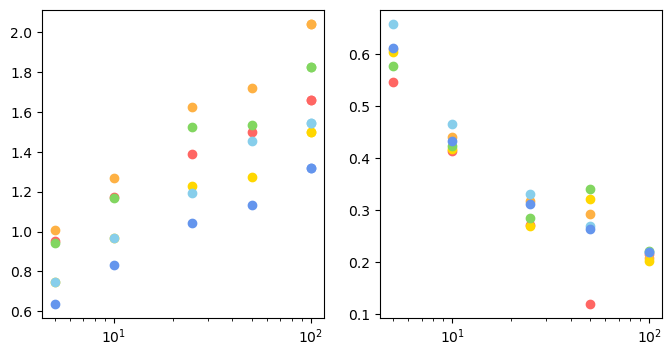

In [7]:
freqs=[100,25,5,10,50,100]

psi={}
phi={}
Zamp={}
Damp={}


T=65
I=47

for n in range(6):
    #fig2,ax2=plt.subplots(len(freqs),2,figsize=(60,12))
    lpsi=[]
    lphi=[]
    lZamp=[]
    lDamp=[]
    
    file=r'example_data\2\PPG-MPU_0210RS_{}.0_000{}.spm'.format(65,I+n)
    with files.ScriptFile(file) as file_:
        n_segs = file_.segments_count
        segs_info = file_.segments_info

        for f in range(len(freqs)):
            i_seg = f+2
            
            channel = file_[0]
            data = channel.get_script_segment_data(i_seg,METRIC)
            time=data.x
            d=data.y
            channel = file_[1]
            data = channel.get_script_segment_data(i_seg,METRIC)
            z=data.y

            #height
            x=time[int(len(z)*0.2):int(len(z)*0.8)]
            y=z[int(len(z)*0.2):int(len(z)*0.8)]
            #ax2[f,0].scatter(x,y,s=10,color="grey")
            
            bounds=[[0,0.1,-np.inf,-np.inf],[np.inf,6,np.inf,np.inf]]
            freq=freqs[f]
            z_guess,z_guess_err = curve_fit(sinewlinearBL,x,y,p0=[1, 5 ,2,  0.02],bounds=bounds)
            yfit=sinewlinearBL(x,*z_guess)
            #ax2[f,0].plot(x,yfit,c='k')
            
            
            #defl
            #ax3=ax2[f,1]
            X=time[int(len(z)*0.2):int(len(z)*0.8)]
            Y=d[int(len(z)*0.2):int(len(z)*0.8)]
            #ax3.scatter(X,Y,s=10,color="purple")
            
            d_guess,d_guess_err = curve_fit(sinewlinearBL,X,Y,p0=[3,4,0,0],bounds=bounds)
            Yfit=sinewlinearBL(X,*d_guess)
            #ax3.plot(X,Yfit,c='plum')
            #print(d_guess)
            
            yfit_noBL=sine(x,z_guess[0],z_guess[1],y.mean())
            lpsi.append(z_guess[1])
            lphi.append(d_guess[1])
            lZamp.append(z_guess[0])
            lDamp.append(d_guess[0])
        psi[n]=lpsi
        phi[n]=lphi
        Zamp[n]=lZamp
        Damp[n]=lDamp

phaseshift=(pd.DataFrame(phi)-pd.DataFrame(psi)-calibration)
DZr=(pd.DataFrame(Damp)/pd.DataFrame(Zamp))
sp=(DZr*(np.cos(phaseshift)-DZr)/((np.cos(phaseshift)-DZr)**2+np.sin(phaseshift)**2))
spp=(DZr*np.sin(phaseshift)/((np.cos(phaseshift)-DZr)**2+np.sin(phaseshift)**2))

a0l=[]
acl=[]
for n in range(6):
    file=r'example_data\2\PPG-MPU_0210RS_{}.0_000{}.spm'.format(65,I+n)
    with files.ScriptFile(file) as file_:
        n_segs = file_.segments_count
        segs_info = file_.segments_info
        i_seg = 8
        
        channel = file_[0]
        data = channel.get_script_segment_data(i_seg,METRIC)
        time=data.x
        d=data.y
        channel = file_[1]
        data = channel.get_script_segment_data(i_seg,METRIC)
        z=data.y
        sep=-z+d
    
    
    retrace=pd.DataFrame({0:sep,1:d})
    
    k=40
    R=25
    blf=20
    fitboundary=[10,80]
    minimum_i=retrace.iloc[:,1].idxmin()
    
    minffb=int((1-fitboundary[0]/100)*minimum_i)
    maxffb=int((1-fitboundary[1]/100)*minimum_i)
    
    #fig,ax=plt.subplots(1,1,constrained_layout=True, figsize = (5,5))
    
    
    baselinefit=retrace.iloc[-blf:,1].mean()
    
    #ax.set(ylabel='force',xlabel='separation')
    retrace[2]=(retrace[1]-baselinefit)*40
    #retrace[2]=retrace[1]
   # ax.plot(retrace[0],retrace[2])
    #ax.scatter(retrace[0][minimum_i],retrace[2][minimum_i],marker='x',color='k')
    
    #ax.axhline(retrace[2][minffb],linestyle='dotted')
    #ax.axhline(retrace[2][maxffb],linestyle='dotted')
    
    consep=retrace[0][minimum_i]-retrace[0][0]
    
    Padh=(retrace[2][minimum_i])
    #print(Padh)
    gamma = -2 * Padh / (3 * np.pi * R)
    #print('gamma:',gamma)
    
    fittingregion=retrace[maxffb:minffb+1]
    
   # ax.plot(fittingregion[0],fittingregion[2])
    
    
    def xterm(p,Padh):
        #Padh=abs(Padh)
        u=(1+np.sqrt(1-p/Padh))/2
        return (u**(4/3)-2/3*u**(1/3))
    
    test=xterm(fittingregion[2],Padh)
    
    #fig,ax=plt.subplots(1,1,figsize=(5,5))
    #ax.scatter(test,fittingregion[0])
    
    m, c = np.polyfit(test, fittingregion[0], 1)
    
    #print(np.sqrt(abs(m)*25))
    
    #print(f"Slope (m): {m}")
    #print(f"Intercept (c): {c}")

    delta=consep
    a0=np.sqrt(abs(m)*25)

    R=25
    ac_initial = a0
    a_solution = fsolve(equation, ac_initial, args=(delta, R, a0))[0]
    acl.append(a_solution)
    a0l.append(a0)

r65={'a0l':a0l,'acl':acl}
t65={'ps':phaseshift,'DZr':DZr,'sp':sp,'spp':spp}
R=r65
N=t65

color=['mediumpurple','cornflowerblue','skyblue','#82D660','gold','#FEB144','#FF6663']
fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].set(xscale='log')
ax[1].set(xscale='log')


eref=(N['sp'].iloc[5,:]/R['acl'])
a1=N['sp'].iloc[0,:]/eref
tl=[0.5,1.5,4,7,8.5]
acall={}
for n in range(5):
    t=9.5-tl[n]
    m=(acl-a1)/-9*t+acl
    acall[n]=m

acall=pd.DataFrame(acall).T
acall=pd.concat([acall,pd.DataFrame(acl,columns=[5]).T],axis=0)


for n in range(6):
    ax[0].scatter(freqs,N['sp'][n]*40/(acall[n]*2),color=color[6-n])
    ax[1].scatter(freqs[:-1],N['spp'][n][:-1]/N['sp'][n][:-1],color=color[6-n])

In [8]:
Nl=[t65]
Rl=[r65]

Ed={}
ltd={}

for k in range(1):

    R=Rl[k]
    N=Nl[k]
    
    eref=(N['sp'].iloc[5,:]/R['acl'])
    a1=N['sp'].iloc[0,:]/eref
    a1=[float(n) for n in a1]
    acl=[float(n) for n in R['acl']]
    tl=[0.5,1.5,4,7,8.5,9.5]
    gradientlist=[(a-b)/-9 for a,b in zip(acl,a1)]
    acall={}
    for n in range(6):
        if n==0:
            m=a1
        else:
            t=9.5-tl[n]
            p=[n*t for n in gradientlist]
            m=[p+f for p,f in zip(p,acl)]
            print(m)
        acall[n]=m
    
    acall=pd.DataFrame(acall).T
    
    Ed[k]=N['sp']*40/(acall*2)
    ltd[k]=N['spp'][:-1]/N['sp'][:-1]

acall

[14.31533892517904, 11.135867851496364, 15.946851298308163, 12.46954010903308, 13.82786473436215, 17.519170059093447]
[14.746912832720833, 11.48389179489951, 16.39088418096294, 12.756964743116926, 14.256932527532687, 17.81143344846153]
[15.264801521770984, 11.901520526983287, 16.92372364014867, 13.101874304017544, 14.771813879337332, 18.162149515703224]
[15.52374586629606, 12.110334893025174, 17.190143369741538, 13.274329084467851, 15.029254555239653, 18.337507549324073]
[15.696375429312777, 12.249544470386432, 17.367756522803447, 13.38929893810139, 15.200881672507869, 18.454412905071305]


,0,1,2,3,4,5
0,14.142709,10.996658,15.769238,12.354570,13.656238,17.402265
1,14.315339,11.135868,15.946851,12.469540,13.827865,17.519170
2,14.746913,11.483892,16.390884,12.756965,14.256933,17.811433
3,15.264802,11.901521,16.923724,13.101874,14.771814,18.162150
4,15.523746,12.110335,17.190143,13.274329,15.029255,18.337508
5,15.696375,12.249544,17.367757,13.389299,15.200882,18.454413


In [9]:
temps=1

Emean=pd.DataFrame(Ed[0].mean(axis=1))
Estd=pd.DataFrame(Ed[0].std(axis=1))

Lmean=pd.DataFrame(ltd[0].mean(axis=1))
Lstd=pd.DataFrame(ltd[0].std(axis=1))

Emean.index=freqs[:]
Emean.sort_index(ascending=True, inplace=True)
Lmean.index=freqs[:-1]
Lmean.sort_index(ascending=True, inplace=True)

Estd.index=freqs[:]
Estd.sort_index(ascending=True, inplace=True)
Lstd.index=freqs[:-1]
Lstd.sort_index(ascending=True, inplace=True)

Emean=Emean.iloc[:-1,:]
Estd=Estd.iloc[:-1,:]

In [10]:
Emean

,0
5,0.838790
10,1.062799
25,1.333418
50,1.436554
100,1.647693


In [11]:
Estd

,0
5,0.147062
10,0.164888
25,0.218974
50,0.206312
100,0.256624


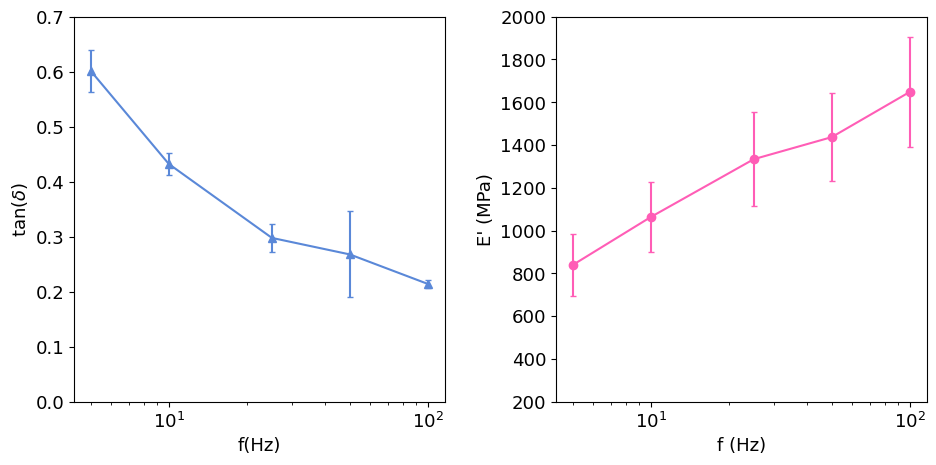

In [12]:
plt.rcParams['font.size']=13
fig1,Ax=plt.subplots(1,2,figsize=(11,5))
f=[5,10,25,50,100]

markers=['^','o']
labels=['tan($\delta$)',"Storage modulus"]


ax1=Ax[0]
ax2=Ax[1]

ax1.errorbar(f,Lmean.iloc[:,0],yerr=Lstd.iloc[:,0],capsize=2,markersize=6,marker='^',color="#5A88D8")
ax2.errorbar(f,Emean.iloc[:,0]*10**3,yerr=Estd.iloc[:,0]*10**3,capsize=2,markersize=6,marker='o',color="#FF5DB6")

ax2.set(ylim=(200,2000),xlabel='f (Hz)',ylabel="E' (MPa)",yscale='linear',xscale='log')
ax1.set(ylim=(0,0.7),ylabel='tan($\delta$)',xlabel='f(Hz)',xscale='log')

plt.subplots_adjust(wspace=0.3)